📷 Bắt đầu quét hóa đơn: d:\VGU\Intro to AI\invoice-reader\Seg_OCR_Tri\input\test3.jpg

0: 640x320 1 receipt, 4.5ms
Speed: 14.8ms preprocess, 4.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 320)

0: 640x320 1 receipt, 5.5ms
Speed: 1.4ms preprocess, 5.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 320)
🔍 OSD dự đoán 0 độ | confidence: 5.90


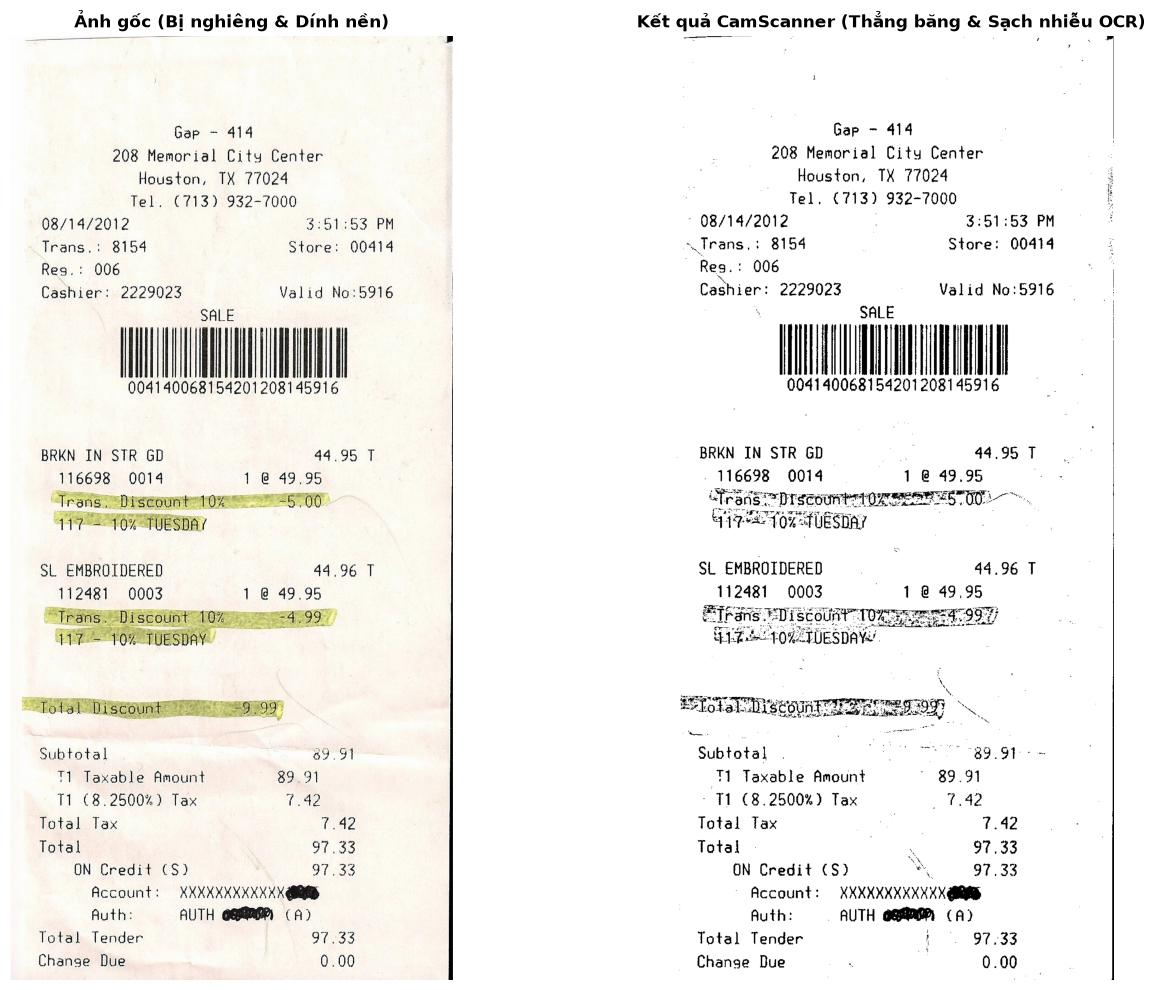

🔥 THÀNH CÔNG RỰC RỠ! Ảnh chuẩn CamScanner đã xuất xưởng tại: D:\VGU\Intro to AI\invoice-reader\Seg_OCR_Tri\outputs\CAMSCANNER_RESULT.jpg
🚀 Đang chạy OCR ngầm trên ảnh...
🧠 Đang nạp mô hình SentenceTransformer và XGBoost...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 13041.66it/s]



🔍 --- BẢNG XẾP HẠNG ỨNG VIÊN TỔNG TIỀN (XGBOOST) ---
Value:      97.33 | Score:  85.7% | Context: 'Total'
Value:      89.91 | Score:  52.9% | Context: ''
Value:  112481.00 | Score:  51.2% | Context: ''
Value:       3.00 | Score:  51.2% | Context: ''
Value:      49.95 | Score:  50.6% | Context: '1@'

💰 KẾT QUẢ CUỐI CÙNG TRÍCH XUẤT ĐƯỢC: 97.33


In [ ]:
import sys
import json
import re
import subprocess
import numpy as np
import pandas as pd
import xgboost as xgb
from pathlib import Path
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# --- 1. SETUP PATHS & SCAN IMAGE ---
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "Seg_OCR_Tri" / "src"))
from main import img_scanner

# Nhập đường dẫn ảnh hóa đơn cần quét (thay đổi file ảnh ở đây)
raw_image = str(project_root / "Seg_OCR_Tri" / "input" / "test3.jpg")
print(f"📷 Bắt đầu quét hóa đơn: {raw_image}")

# Chạy mô hình YOLO định vị và cắt nền (CamScanner)
image_input = img_scanner(raw_image)
if image_input is None:
    raise ValueError("❌ Quét hóa đơn thất bại, không tìm thấy vùng hóa đơn!")

# Các file AI xử lý trích xuất được đặt hoàn toàn trong Candidate_classification (Theo yêu cầu)
ocr_results_file = "temp_ocr_results.json"
worker_script = "ocr_worker.py"  # File này dùng chung cho cả folder lẫn 1 ảnh
xgb_model_path = "xgb_total_model.json"

# --- 2. CHẠY PADDLE_OCR NGẦM (TRÁNH XUNG ĐỘT BỘ NHỚ VỚI PYTORCH) ---
print("🚀 Đang chạy OCR ngầm trên ảnh...")
subprocess.run([sys.executable, worker_script, image_input, ocr_results_file], check=True)

with open(ocr_results_file, "r", encoding="utf-8") as f:
    ocr_output = json.load(f)

real_ocr_data = ocr_output["ocr_data"]
real_img_height = ocr_output["img_height"]

# --- 3. KHỞI TẠO CÁC MÔ HÌNH AI (PYTORCH & XGBOOST) ---
print("🧠 Đang nạp mô hình SentenceTransformer và XGBoost...")
embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
POSITIVE_VECTOR = embedding_model.encode(["order total, total amount to pay, grand total, final total, total, tổng cộng, tổng"])[0]
NEGATIVE_VECTOR = embedding_model.encode(["tax, transaction ID, reference code, authorization, phone number, date, time, credit card, subtotal, tax amount, change due, item code, sku, barcode"])[0]

xgb_model = xgb.XGBClassifier()
xgb_model.load_model(xgb_model_path)

# --- 4. HÀM TRÍCH XUẤT ĐẶC TRƯNG & DỰ ĐOÁN ---
def predict_total_with_xgboost(easyocr_results, img_height):
    CURRENCY_PATTERN = re.compile(r'[\$€£¥₩₹₽₺₴₦฿₫₱¢]|USD|EUR|VND|JPY|GBP|AUD|CAD|SGD', re.IGNORECASE)
    metadata_blacklist = ['tax', 'id', 'code', 'trn', 'auth', 'seq', 'acq', 'phone', 'tel', 'date', 'time', 'mastercard', 'visa', 'cashier', 'store', 'register', 'pm', 'am', 'terminal']
    
    candidates = []
    for idx, res in enumerate(easyocr_results):
        bbox, text = res
        text_clean = text.strip()
        for match in re.finditer(r'\b\d+(?:[\.,:]\d+)*\b', text_clean):
            num_str = match.group()
            start_idx, end_idx = match.span()
            raw_digits = re.sub(r'\D', '', num_str)
            if not raw_digits or len(raw_digits) > 12: continue
            s = num_str.replace(' ', '')
            if '.' in s or ',' in s or ':' in s:
                sep = '.' if '.' in s else (',' if ',' in s else ':')
                parts = s.split(sep)
                last_part = parts[-1]
                if len(last_part) == 2:
                    main_part = ''.join(parts[:-1]).replace('.', '').replace(',', '')
                    clean_val = float(f"{main_part}.{last_part}")
                else:
                    clean_val = float(s.replace('.', '').replace(',', '').replace(':', ''))
            else:
                clean_val = float(s)
            y_center = np.mean([point[1] for point in bbox])
            normalized_y = y_center / img_height
            left_window = text_clean[max(0, start_idx - 25):start_idx]
            right_window = text_clean[end_idx:min(len(text_clean), end_idx + 15)]
            has_letters = bool(re.search(r'[a-zA-Z]', left_window))
            has_numbers = bool(re.search(r'\d', left_window))
            if not has_letters and not has_numbers and idx > 0:
                potential_prev_line = easyocr_results[idx - 1][1]
                if not re.search(r'\d', potential_prev_line):
                    prev_line = potential_prev_line[-25:]
                else:
                    prev_line = ''
            else:
                prev_line = ''
            neighbor_text = f"{prev_line} {left_window} {right_window}".strip()
            if not neighbor_text:
                continue
            candidates.append({'value': clean_val, 'normalized_y': normalized_y, 'neighbor_text': neighbor_text})
            
    if not candidates:
        print("❌ OCR không tìm thấy bất kỳ con số nào.")
        return None
        
    for cand in candidates:
        cand['has_currency'] = 1.0 if CURRENCY_PATTERN.search(cand['neighbor_text']) else 0.0
        cand['text_length'] = len(cand['neighbor_text'])
        if cand['neighbor_text']:
            if not re.search(r'[a-zA-Z]', cand['neighbor_text']): cand['semantic_sim'] = 0.0
            else:
                cand_vector = embedding_model.encode([cand['neighbor_text']])[0]
                pos_sim = cosine_similarity([cand_vector],[POSITIVE_VECTOR])[0][0]
                neg_sim = cosine_similarity([cand_vector],[NEGATIVE_VECTOR])[0][0]
                if pos_sim < 0.25 or neg_sim > pos_sim: cand['semantic_sim'] = 0.0
                else: cand['semantic_sim'] = pos_sim
                if any(w in cand['neighbor_text'].lower() for w in metadata_blacklist): cand['semantic_sim'] *= 0.1
        else:
            cand['semantic_sim'] = 0.0
            
    valid_max_values = []
    for c in candidates:
        is_barcode_format = (c['value'].is_integer() and len(str(int(c['value']))) >= 5 and c['semantic_sim'] < 0.3)
        if c['semantic_sim'] > 0.1 and not is_barcode_format:
            valid_max_values.append(c['value'])
            
    max_bill_value = max(valid_max_values) if valid_max_values else max([c['value'] for c in candidates])
    
    features_list = []
    for cand in candidates:
        is_max = 1.0 if cand['value'] == max_bill_value else 0.0
        features_list.append({
            'semantic_sim': float(cand['semantic_sim']),
            'normalized_y': float(cand['normalized_y']),
            'is_max': float(is_max),
            'text_length': float(cand['text_length']),
            'has_currency': float(cand['has_currency']),
            'value': cand['value'],
            'neighbor_text': cand['neighbor_text']
        })
        
    df_features = pd.DataFrame(features_list)
    X_pred = df_features[['semantic_sim', 'normalized_y', 'is_max', 'text_length', 'has_currency']]
    probabilities = xgb_model.predict_proba(X_pred)[:, 1]
    for i, cand in enumerate(features_list): cand['xgb_score'] = float(probabilities[i])
    best_candidate = max(features_list, key=lambda x: x['xgb_score'])
    
    print("\n🔍 --- BẢNG XẾP HẠNG ỨNG VIÊN TỔNG TIỀN (XGBOOST) ---")
    sorted_cands = sorted(features_list, key=lambda x: x['xgb_score'], reverse=True)[:5]
    for c in sorted_cands:
        print(f"Value: {c['value']:>10.2f} | Score: {c['xgb_score']*100:>5.1f}% | Context: '{c['neighbor_text']}'")
        
    MIN_CONFIDENCE = 0.4
    if best_candidate['xgb_score'] < MIN_CONFIDENCE:
        print("\n⚠️ THẤT BẠI: Cảnh báo AI không đủ tự tin để chốt số Tổng.")
        return None
    return best_candidate['value']

# --- 5. THỰC THI ---
final_total_money = predict_total_with_xgboost(real_ocr_data, real_img_height)
print(f"\n💰 KẾT QUẢ CUỐI CÙNG TRÍCH XUẤT ĐƯỢC: {final_total_money}")
